# TRUST Additional Validation Data

## First combine data from genotypic samples and patients

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, sparse, itertools, subprocess, sys, pickle, re, collections, shutil
from functools import reduce

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st
import warnings
warnings.filterwarnings("ignore")

from matplotlib.ticker import FormatStrFormatter
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
import statsmodels.stats.api as sm

results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
model_loci = pd.read_csv("../../data_processing/data_utils/drug_loci.csv")

from epi_utils import *

# # who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
# who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_resistance_variants_all.csv")
# who_variants_clean = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_genes_v4.csv")

# coll2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
# coll2014["#lineage"] = coll2014["#lineage"].str.replace("lineage", "")
# coll2014.rename(columns={"#lineage": "Lineage"}, inplace=True)

# solo_results = pd.read_excel("/home/sak0914/who-analysis/data/SOLO primary_STATA_ver18Feb2023.xlsx", sheet_name=None)

# if len(solo_results) == 1:
#     solo_results = solo_results[list(solo_results.keys())[0]]

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETO",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMK",
                  "Pretomanid": "PMD",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LFX",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {val: key for key, val in drug_abbr_dict.items()}

# isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/WHO_catalog_isolate_variants.csv")

who_variants = pd.read_csv("../../data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
silent_lst = ['synonymous_variant', 'initiator_codon_variant', 'stop_retained_variant']
isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/isolate_variants_WHO_catalog.csv")
isolate_variants_full = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/isolate_variants_WHO_catalog.csv")

cc_df = pd.read_csv("/home/sak0914/who-analysis/data/drug_CC.csv")

# MIC encoding from the TRUST codebook
MIC_encoding_dicts = {'RIF': {1: '0,0.03', 2: '0.03,0.06', 3: '0.06,0.125', 4: '0.125,0.25', 5: '0.25,0.5', 6: '0.5,1', 7: '1,inf'},
                      'INH': {1: '0,0.025', 2: '0.025,0.05', 3: '0.05,0.1', 4: '0.1,0.2', 5: '0.2,inf'},
                      'EMB': {1: '0,0.6', 2: '0.6,1.25', 3: '1.25,2.5', 4: '2.5,5', 5: '5,inf'},
                      'PZA': {1: '0,25', 2: '25,50', 3: '50,75', 4: '75,100', 5: '100,inf'}
                     }

RIF_label_encoding_dict = {1: '≤0.03', 2: '0.03-0.06', 3: '0.06-0.125', 4: '0.125-0.25', 5: '0.25-0.5', 6: '0.5-1', 7: '>1'}
INH_label_encoding_dict = {1: '≤0.025', 2: '0.025-0.05', 3: '0.05-0.1', 4: '0.1-0.2', 5: '>0.2'}
EMB_label_encoding_dict = {1: '≤0.6', 2: '0.6-1.25', 3: '1.25-2.5', 4: '2.5-5', 5: '>5'}
PZA_label_encoding_dict = {1: '≤25', 2: '25-50', 3: '50-75', 4: '75-100', 5: '>100'}

MIC_label_encoding_dicts = {'RIF': RIF_label_encoding_dict, 'INH': INH_label_encoding_dict, 'EMB': EMB_label_encoding_dict, 'PZA': PZA_label_encoding_dict}

In [2]:
def boundedLoss_predict(pred_df, y_pred_col="y_pred", lower_bounds_col="lower", upper_bounds_col="upper"):
    '''
    y_true and y_pred are log-MICs. lower_bounds and upper_bounds are exponentiated. 
    
    This function returns bounded MAE, MSE, and the proportion of points measured within 1 MIC doubling (1 log2 unit)
    ''' 
    
    del_cols = [f"{y_pred_col}_exp", "within_doubling", "within_1bin", "compute_error", f"{lower_bounds_col}_rounded", f"{upper_bounds_col}_rounded"]

    for col in del_cols:
        if col in pred_df.columns:
            del pred_df[col]

    # first add essential agreement (proportion within 1 doubling dilution)
    # not always helpful because some "doubling" dilutions are not exact, i.e. 0.3, 0.6, 0.125, 0.5. But the number is here if needed
    pred_df[f"{y_pred_col}_exp"] = np.round(np.exp2(pred_df[y_pred_col]).astype(float), 2)
    
    pred_df.loc[(pred_df[lower_bounds_col] / 2 <= pred_df[f"{y_pred_col}_exp"]) & 
                (pred_df[upper_bounds_col] * 2 >= pred_df[f"{y_pred_col}_exp"])
                , "within_doubling"] = 1

    pred_df.loc[(pred_df[f"{y_pred_col}_exp"] == 0.06) & (pred_df[lower_bounds_col] == 0.12), "within_doubling"] = 1
    pred_df["within_doubling"] = pred_df["within_doubling"].fillna(0).astype(int)
        
    # make copies to avoid changing the original dataframe
    lower_bounds = np.copy(pred_df[lower_bounds_col].values) #pred_df[lower_bounds_col].values / 2
    upper_bounds = np.copy(pred_df[upper_bounds_col].values) #pred_df[upper_bounds_col].values * 2
    
    lower_bounds[lower_bounds==0] += 1e-10
    lower_bounds = np.log2(lower_bounds)
    upper_bounds = np.log2(upper_bounds)

    # use less than or equal to because the true MIC is in the range (lower, upper], so it is not equal to lower.
    pred_df["compute_error"] = ((pred_df[y_pred_col].values <= lower_bounds) | (pred_df[y_pred_col].values > upper_bounds)).astype(int)

    # compute the error relative to the bounds, NOT RELATIVE TO THE MIDPOINT (y_test) of each isolate
    # np.clip returns one of the values from lower_bounds or upper_bounds, whichever is closest to the prediction, if the value is outside the bounds
    # if the test values are within the bounds, the values themselves are returned
    bound_to_compute_error = np.clip(pred_df[y_pred_col].values, lower_bounds, upper_bounds)
    mae = np.mean((np.abs(bound_to_compute_error - pred_df[y_pred_col])))
    mse = np.mean((np.square(bound_to_compute_error - pred_df[y_pred_col])))

    return mae, mse, pred_df["within_doubling"].mean()

# Read in all data

In [3]:
# df_trust_patients = pd.read_csv("./processed_data/20240925_combined_patients_WGS_samples_all.csv")
df_trust_patients, TRUST_phenos, df_pred_combined = read_combine_all_TRUST_data("./processed_data/combined_patient_WGS_data.csv", 
                                                                                {'RIF': 'lineage_amino_acid', 
                                                                                 'INH': 'lineage_amino_acid', 
                                                                                 'EMB': 'lineage_amino_acid', 
                                                                                 'PZA': 'amino_acid'}, # dictionary for which model to get predictions for
                                                                                CNN_results_dir="/n/data1/hms/dbmi/farhat/Sanjana/CNN_results", 
                                                                                baseline_only=True
                                                                               )

# # from Brendon email September 5, 2024
# df_trust_patients.loc[(pd.isnull(df_trust_patients['s_inhmicmeth_sputum_specimen_1'])) & (~pd.isnull(df_trust_patients['s_inhmic_sputum_specimen_1'])), 's_inhmicmeth_sputum_specimen_1'] = 3
# df_trust_patients.loc[df_trust_patients['pid']=='T0097', 's_inhmicmeth_sputum_specimen_2'] = 2
# df_trust_patients.loc[df_trust_patients['pid']=='T0063', 's_inhmicmeth_sputum_specimen_2'] = 3

# additional email from Brendon November 27, 2024:
# df_trust_patients.loc[df_trust_patients['pid']=='T0466', 's_embmicmeth_sputum_specimen_1'] = 2
# df_trust_patients.loc[df_trust_patients['pid']=='T0470', 's_rifmicmeth_sputum_specimen_1'] = 2

# # from Noorjahn's email on December 20, 2024:
# # INH MIC for sample S0108-01 was retested in duplicate in MGIT, giving an MIC of > 0.1, so update s_inhmic_sputum_specimen_1 to 5
# df_trust_patients.loc[df_trust_patients['pid']=='T0108', ['s_inhmicmeth_sputum_specimen_1', 's_inhmic_sputum_specimen_1']] = [2, 5]

# # INH MIC for sample S0108-08 was retested in triplicate in MGIT, giving MIC = 0.1-0.25, so update s_inhmic_sputum_specimen_1 to 4
# df_trust_patients.loc[df_trust_patients['pid']=='T0108', ['s_inhmicmeth_sputum_specimen_8', 's_inhmic_sputum_specimen_8']] = [2, 4]

# # INH MIC for sample S0030-01 was retested in MGIT, giving an MIC of 0.1. There was intermediate growth, so could be heteroresistance?
# # update s_inhmicmeth_sputum_specimen_1 to 2 (MGIT) and s_inhmic_sputum_specimen_1 to 3 (0.05-0.1)
# df_trust_patients.loc[df_trust_patients['pid']=='T0030', ['s_inhmicmeth_sputum_specimen_1', 's_inhmic_sputum_specimen_1']] = [2, 3]

418 patients with any WGS samples
418 patients with uncontaminated WGS samples
408 patients with uncontaminated WGS samples taken in the first 2 weeks

2 patients: ['T0137' 'T0402'] have multiple sequences at the same timepoint
Removing 1 patients: ['T0402'] because there are multiple WGS samples at the same timepoint with different lineages
409 patients have MICs for RIF
409 patients have MICs for INH
409 patients have MICs for EMB
288 patients have MICs for PZA
405 patients have measured MICs in the first 2 weeks

Found predicted RIF MICs for 407 pids
Found predicted INH MICs for 407 pids
Found predicted EMB MICs for 407 pids
Found predicted PZA MICs for 407 pids
407 patients have predicted MICs


# Create summary figure of the MICs of the 4 first-line drugs (these are the only MICs that were tested)

In [4]:
# # 1 = microtiter plate, 2 = MGIT, 3 = Other
# # For RIF and EMB, MGIT and 7H10 CCs are the same. For PZA, model MICs are in MGIT anyway
# # for drug in ['RIF', 'INH', 'EMB', 'PZA']:
#     for col in df_trust_patients.columns[df_trust_patients.columns.str.contains(f'{drug.lower()}micmeth')]:
#         if sum(~pd.isnull(df_trust_patients[col])) != 0:
#             print(drug, col, df_trust_patients.dropna(subset=col)[col].value_counts())

In [5]:
# read in again with the categorial values, not converted to actual MICs
# hmm, but this doesn't consider the fact that some of the INH values were measured in MGIT....
TRUST_phenos_categorical = []

for drug in drugs_lst:
    
    # this contains all WGS runs, so keep only the unique pids for counting/plotting purposes
    # all MICs here were converted to MGIT. The only drug for which that makes any difference is INH, whose MGIT (0.1) and 7H10 (0.2) critical concentrations are different.
    df_single_drug = get_all_available_MICs_single_drug(df_trust_patients, drug, baseline_only=True)
    df_single_drug = df_single_drug[['pid', drug, f"{drug}_method"]].drop_duplicates()

    df_single_drug[f"{drug}_method"] = df_single_drug[f"{drug}_method"].fillna('MGIT')
    
    print(f"{len(df_single_drug)} patients have MICs for {drug}")
    TRUST_phenos_categorical.append(df_single_drug)

TRUST_phenos_categorical = reduce(lambda left, right: pd.merge(left, right, on='pid', how='outer'), TRUST_phenos_categorical)

405 patients have MICs for RIF
405 patients have MICs for INH
405 patients have MICs for EMB
287 patients have MICs for PZA


In [6]:
final_keep_pids = pd.read_csv("final_keep_pids.txt", sep='\t', header=None)[0].values
print(f"Kept {len(final_keep_pids)} pids for survival models")

Kept 362 pids for survival models


In [7]:
TRUST_plot_phenos = pd.DataFrame(TRUST_phenos_categorical.query("pid in @final_keep_pids").melt(id_vars="pid").query("~variable.str.contains('method')")[["variable", "value"]].value_counts()).reset_index()

TRUST_plot_phenos.columns = ["Drug", "MIC_group", "Count"]

TRUST_plot_phenos["Drug"] = TRUST_plot_phenos["Drug"].map(abbr_drug_dict)

In [8]:
TRUST_plot_phenos.groupby('Drug')['Count'].sum()

Drug
Ethambutol      361
Isoniazid       361
Pyrazinamide    257
Rifampicin      361
Name: Count, dtype: int64

In [9]:
TRUST_plot_phenos.query("Drug=='Ethambutol'")

,Drug,MIC_group,Count
0,Ethambutol,2.0,243
6,Ethambutol,1.0,83
9,Ethambutol,3.0,33
17,Ethambutol,5.0,2


In [10]:
30/361, 2/357

(0.08310249307479224, 0.0056022408963585435)

In [11]:
def create_stacked_percent_bar_chart(df, x_order, palettes, index_var="Drug", col_var="MIC_group", count_var="Count", saveName=None):

    # add these to the x labels
    totals_dict = dict(df.groupby('Drug')['Count'].sum())

    # set the figure size
    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    df_stacked_for_plotting = df.pivot(index=index_var, columns=col_var, values=count_var).fillna(0).astype(int)
    df_stacked_for_plotting["Total"] = df_stacked_for_plotting.sum(axis=1)

    # compute proportions for plotting
    for group in df[col_var].unique():
        df_stacked_for_plotting[group] = df_stacked_for_plotting[group] / df_stacked_for_plotting["Total"]
        
    del df_stacked_for_plotting["Total"]
    df_stacked_for_plotting = df_stacked_for_plotting.reset_index().melt(id_vars=index_var)
        
    # keep track of all the groups to increase the start value of the next bar
    prev_vals_array = np.zeros(len(df_stacked_for_plotting[index_var].unique()))
    
    # order in increasing lineage abundance for each drug
    df_stacked_for_plotting = df_stacked_for_plotting.sort_values([index_var, "value"], ascending=[True, False])

    # add string labels to the dataframe. Use these to label the bar segments with
    for i, row in df_stacked_for_plotting.iterrows():

        # get the appropriate label encoding dictionary
        drug_label_encoding_dict = MIC_label_encoding_dicts[drug_abbr_dict[row['Drug']]]

        # get the appropriate MIC bound label
        df_stacked_for_plotting.loc[i, "Label"] = drug_label_encoding_dict[row[col_var]]
    
    # reorder the dataframe to match the plotting order so that we can add bar labels properly
    # Convert the 'Category' column to Categorical data type with the desired order
    df_stacked_for_plotting[f'{col_var}_categorical'] = pd.Categorical(df_stacked_for_plotting[index_var], categories=x_order, ordered=True)
    df_stacked_for_plotting = df_stacked_for_plotting.sort_values([col_var, f'{col_var}_categorical']).reset_index(drop=True)
    
    # iterate through the Lineages and convert to percentages
    column_groups = df_stacked_for_plotting[col_var].unique()
    
    for i, column_group in enumerate(column_groups):  
                        
        # dataframe of proportion of each drug's samples that belong to the current lineage
        single_group = df_stacked_for_plotting[df_stacked_for_plotting[col_var]==column_group].groupby(index_var)["value"].sum().reset_index()
        single_group = single_group.set_index(index_var).loc[x_order, :].reset_index()
        
        if i > 0:
            prev_vals = df_stacked_for_plotting[df_stacked_for_plotting[col_var]==column_groups[i-1]].groupby(index_var)["value"].sum().reset_index()
            prev_vals = prev_vals.set_index(index_var).loc[x_order, :].reset_index()["value"].values 
            prev_vals_array += prev_vals
            
        ax.bar(single_group[index_var].values, 
               single_group["value"].values, 
               bottom = prev_vals_array, 
               edgecolor="black",
               label=column_group,
               width=0.5
              )       
    
    label_loc = 'center'
    sigfig = 2
    font_size = '7'

    # Get the patches from ax
    patches = ax.get_children()
    rect_patches = [patch for patch in patches if isinstance(patch, plt.Rectangle)]
    
    # variable to iterate over the product of len(col_var) * len(index_var). In this case, = 15
    count_idx = -1
    num_drugs = len(x_order)
    # len(ax.containers) = the number of unique values in col_var
    for cont in ax.containers:
        
        labels = []

        # len(cont) = the number of unique values in index_var
        for val in cont.datavalues:

            # iterate for every value
            count_idx += 1

            # update the patch color
            use_palette = palettes[count_idx % num_drugs]
            new_color = use_palette[count_idx // num_drugs]
            rect_patches[count_idx].set_facecolor(new_color)
            
            if val > 0.025:
                labels.append(df_stacked_for_plotting["Label"].values[count_idx])
            else:
                labels.append("")

        ax.bar_label(cont, labels=labels, label_type=label_loc, fontsize=font_size)

    # fig.canvas.draw()

    # isoniazid
    text = ax.text(
        x=1,  # x-coordinate of the text
        y=1.012,  # y-coordinate of the text
        s='>0.2',  # text content
        fontsize=7,  # font size of the text
        color='black',  # color of the text
        ha='center',  # horizontal alignment of the text (optional)
        va='center'  # vertical alignment of the text (optional)
    )

    # ethambutol
    text = ax.text(
        x=2,  # x-coordinate of the text
        y=1.012,  # y-coordinate of the text
        s='>5',  # text content
        fontsize=7,  # font size of the text
        color='black',  # color of the text
        ha='center',  # horizontal alignment of the text (optional)
        va='center'  # vertical alignment of the text (optional)
    )
    
    # pyrazinamide
    text = ax.text(
        x=3,  # x-coordinate of the text
        y=0.982,  # y-coordinate of the text
        s='75-100',  # text content
        fontsize=6,  # font size of the text
        color='black',  # color of the text
        ha='center',  # horizontal alignment of the text (optional)
        va='center'  # vertical alignment of the text (optional)
    )

    text = ax.text(
        x=3,  # x-coordinate of the text
        y=1.012,  # y-coordinate of the text
        s='>100',  # text content
        fontsize=7,  # font size of the text
        color='black',  # color of the text
        ha='center',  # horizontal alignment of the text (optional)
        va='center'  # vertical alignment of the text (optional)
    )

    plt.xticks(ticks=ax.get_xticks(), labels=[f"{label.get_text()}\nN = {totals_dict[label.get_text()]}" for label in ax.get_xticklabels()], fontsize="8")
    plt.yticks(fontsize="7")
    plt.ylabel("Proportion", fontsize="8")
    plt.title("Measured MICs in MGIT Testing Method")
    plt.setp(ax.patches, linewidth=0.75)
    plt.ylim(0, 1.025)
    sns.despine()
    
    if saveName is not None:
        plt.savefig(saveName, bbox_inches='tight')
    else:
        plt.show()

    return df_stacked_for_plotting.reset_index(drop=True)

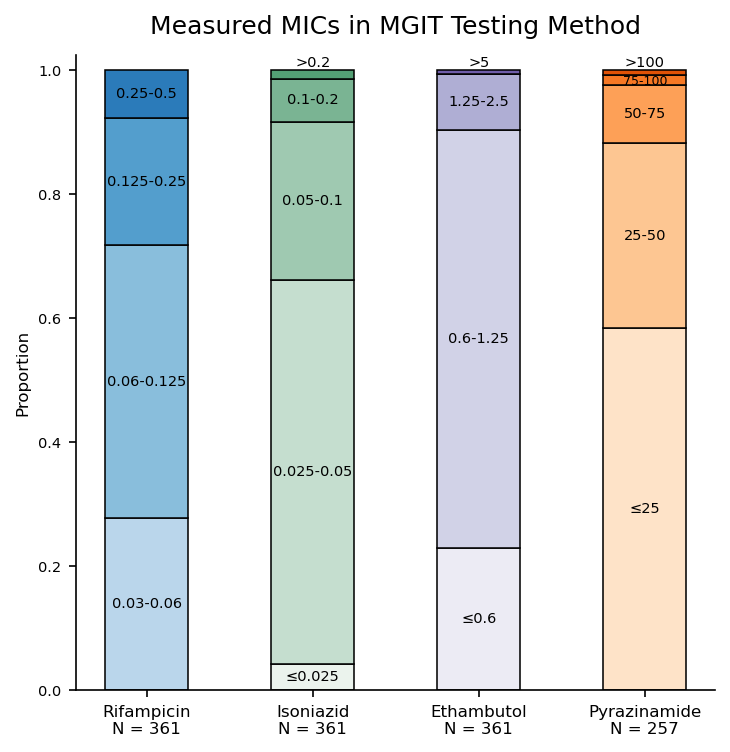

In [12]:
index_var = "Drug"
col_var = "MIC_group"
count_var = "Count"
x_order = ["Rifampicin", "Isoniazid", "Ethambutol", "Pyrazinamide"]

df_stacked_for_plotting = create_stacked_percent_bar_chart(TRUST_plot_phenos, 
                                                           x_order, 
                                                           palettes=[sns.color_palette("Blues").as_hex(),
                                                                     sns.light_palette("seagreen").as_hex(),
                                                                     sns.color_palette("Purples").as_hex(),
                                                                     sns.color_palette("Oranges").as_hex(),
                                                                    ],
                                                           index_var="Drug", 
                                                           col_var="MIC_group", 
                                                           count_var="Count",
                                                           saveName="./figures/phenos_barchart.svg"
                                                          )

In [13]:
def get_TRUST_predicted_and_actual_MICs(drug, model_path, MIC_encoding_dict):

    mic_col = drug #f"s_{drug.lower()}mic_sputum_specimen_1"
    method_col = f"{drug}_method"
    MIC_encoding_dict_rev = {val: key for key, val in MIC_encoding_dict.items()}

    # combine with the WGS sample IDs
    TRUST_phenos_for_merge = TRUST_phenos_categorical.merge(df_trust_patients[['pid', 'Original_ID', 'SampleID', 'sample_collection_week']], on='pid', how='left').query("pid in @final_keep_pids")

    # df_TRUST_MICs = get_all_available_MICs_single_drug(drug)
    df_TRUST_predict = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/{model_path}/TRUST/test_predictions.csv")

    # normalize the MICs to 7H10 if the MGIT MIC is different from the 7H10 MIC
    drug_full_name = abbr_drug_dict[drug]

    # keep only patients with measured MICs, remove samples with a high F2 score
    # keep all WGS runs, even though multiple WGS runs map to a single pid (a single patient's sample has been sequenced multiple times)
    df_TRUST_predict = df_TRUST_predict[['ROLLINGDB_ID', 'log2_pred_MIC', 'pred_MIC']].merge(TRUST_phenos_for_merge[['SampleID', 'Original_ID', 'pid', mic_col, method_col]], left_on='ROLLINGDB_ID', right_on='SampleID')
    
    # convert the MIC categorical variable to a lower bound and upper bound and then combine with the original categorial and method columns
    df_TRUST_predict_actual_MICs = convert_categorical_to_actual_MICs(df_TRUST_predict, drug, MIC_encoding_dict)
    df_TRUST_predict_actual_MICs = df_TRUST_predict_actual_MICs.merge(df_TRUST_predict[['pid', mic_col, method_col]], on='pid').drop_duplicates()
    
    # deduplicate, keeping the earliest WGS sample taken
    df_TRUST_predict_actual_MICs = df_TRUST_predict_actual_MICs.sort_values(['pid', 'Original_ID']).drop_duplicates('pid', keep='first')

    # convert the predicted MICs to MGIT, which is the majority scale of the measured MICs, so it's easiest to convert everything to MGIT for interpretation
    # CNN PZA MICs were in MGIT, so no need to convert
    if drug != 'PZA':

        # these were the only two methods used (7H11 = agar proportion method)
        cc_7H10 = cc_df.query("Drug==@drug_full_name & Medium == '7H10'")['Value'].values[0]
        cc_MGIT = cc_df.query("Drug==@drug_full_name & Medium == 'MGIT'")['Value'].values[0]

        # convert the predicted MICs, which for RIF/INH/EMB are in 7H10, to MGIT by multiplying by the ratio of MGIT CC to 7H10 CC
        df_TRUST_predict_actual_MICs['pred_MIC'] *= cc_MGIT / cc_7H10

    return df_TRUST_predict_actual_MICs

In [14]:
def compare_predicted_actual_MIC(drug, model_path, plot=True, palette="Blues", model="CNN", saveName=None):

    MIC_encoding_dict = MIC_encoding_dicts[drug]
    label_encoding_dict = MIC_label_encoding_dicts[drug]
    
    if model not in ["CNN", "Reg"]:
        raise ValueError(f"{model} must be 'CNN' or 'Reg'")
        
    df_patient_data = get_TRUST_predicted_and_actual_MICs(drug, model_path, MIC_encoding_dict)
    
    # compute binned mae. Don't need mse and within_doubling
    mae, _, _ = boundedLoss_predict(df_patient_data, y_pred_col="log2_pred_MIC", lower_bounds_col=f"{drug}_lower_bound", upper_bounds_col=f"{drug}_upper_bound")
    
    # in get_TRUST_predicted_and_actual_MICs, we converted pred_MIC to the MGIT scale from 7H10, and log2_pred_MIC_exp is in the 7H10 scale, so remove to avoid confusion
    if 'log2_pred_MIC_exp' in df_patient_data.columns:
        del df_patient_data['log2_pred_MIC_exp']

    mic_col = "pred_MIC"
    plot_col = "pred_MIC_group"
    
    # get the bin in which each measured MIC falls. Need to do this because for isoniazid, the 7H11 and MGIT scales are different, so the bin will be different
    for group, bounds_str in MIC_encoding_dict.items():
        lower_bound, upper_bound = np.array(bounds_str.split(",")).astype(float)
        
        # have to make the lower bound inclusive for cases like ≥ 0.1
        df_patient_data.loc[(df_patient_data[f"{drug}_midpoint"] >= lower_bound) & (df_patient_data[f"{drug}_midpoint"] <= upper_bound), drug] = group

    # get the bin in which each predicted MIC falls
    for group, bounds_str in MIC_encoding_dict.items():
        lower_bound, upper_bound = np.array(bounds_str.split(",")).astype(float)
        df_patient_data.loc[(df_patient_data[mic_col] > lower_bound) & (df_patient_data[mic_col] <= upper_bound), plot_col] = group

    categories = list(MIC_encoding_dict.keys())

    # make a matrix of the overlap between the actual and predicted bins
    overlap = pd.crosstab(df_patient_data[drug], df_patient_data[plot_col])

    # reverse the y-ticks (index) because by default they are increasing DOWN, but we want them to increase UP
    overlap = overlap.reindex(index=categories[::-1], columns=categories, fill_value=0)
    
    # Create the heatmap
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(overlap, annot=True, cmap=palette, linewidths=0.25, linecolor="black", ax=ax, clip_on=False, fmt='g')
    
    old_labels = [float(val.get_text()) for val in ax.get_xticklabels()]
    new_labels = pd.Series(old_labels).map(label_encoding_dict)
    
    ax.set_xticks(ticks=ax.get_xticks(), labels=new_labels, fontsize="7")

    # reverse the y-ticks because by default they are increasing DOWN, but we want them to increase UP
    ax.set_yticks(ticks=ax.get_yticks(), labels=new_labels[::-1], rotation=0, fontsize="7")
    
    plt.xlabel("\nPredicted MIC (µg/mL)", fontsize="10")
    plt.ylabel("Actual MIC (µg/mL)", fontsize="10")
    
    sns.despine()

    categorial_accuracy = df_patient_data.query(f"{drug} == {plot_col}").shape[0] / len(df_patient_data)
    essential_agreement = df_patient_data.query(f"~(({drug} - {plot_col} > 1) | ({plot_col} - {drug} > 1))").shape[0] / len(df_patient_data)

    plt.title(f"Categorical Accuracy: {np.round(categorial_accuracy * 100, 1)}%\nEsssential Agreement: {np.round(essential_agreement * 100, 1)}%")

    if plot:
        if saveName is None:
            plt.show()
        else:
            if not os.path.isdir(os.path.dirname(saveName)):
                os.makedirs(os.path.dirname(saveName))
            plt.savefig(saveName, bbox_inches="tight")
    else:
        plt.close()
        
    return df_patient_data, categorial_accuracy, essential_agreement, mae

# All Drugs Summary

In [16]:
df_results_all_models = pd.DataFrame(columns = ['Drug', 'Model', 'Accuracy', 'EA', 'MAE'])
i = 0

for drug in drugs_lst:

    _, categorial_accuracy, essential_agreement, mae = compare_predicted_actual_MIC(drug, f"CNN_results/{drug}_amino_acid", plot=False, model="CNN")
    df_results_all_models.loc[i, :] = [abbr_drug_dict[drug], '– Lineage', categorial_accuracy, essential_agreement, mae]
    i += 1

    _, categorial_accuracy, essential_agreement, mae = compare_predicted_actual_MIC(drug, f"CNN_results/{drug}_lineage_amino_acid", plot=False, model="CNN")
    df_results_all_models.loc[i, :] = [abbr_drug_dict[drug], '+ Lineage', categorial_accuracy, essential_agreement, mae]
    i += 1

In [17]:
df_results_all_models.query("Model == '+ Lineage'")

,Drug,Model,Accuracy,EA,MAE
1,Rifampicin,+ Lineage,0.382271,0.825485,0.409612
3,Isoniazid,+ Lineage,0.67313,0.969529,0.193327
5,Ethambutol,+ Lineage,0.534626,0.939058,0.221326
7,Pyrazinamide,+ Lineage,0.407202,0.933518,0.325621


In [18]:
df_results_all_models.query("Drug=='Pyrazinamide'")

,Drug,Model,Accuracy,EA,MAE
6,Pyrazinamide,– Lineage,0.33241,0.958449,0.203189
7,Pyrazinamide,+ Lineage,0.407202,0.933518,0.325621


In [20]:
df_test_data_results = pd.read_csv("~/MtbQuantCNN/model_results_combined.csv")

In [21]:
for drug in drugs_lst:
    drug = abbr_drug_dict[drug]
    print(drug, df_test_data_results.query("Drug == @drug & Model=='CNN' & Addl_Data=='+ Lineage'")['Within_doubling'].mean())

Rifampicin 0.8731136166522117
Isoniazid 0.8771333885666943
Ethambutol 0.8984476715072608
Pyrazinamide 0.7765853658536586


In [22]:
for drug in drugs_lst:
    print(drug, TRUST_phenos.query("pid in @final_keep_pids")[f"{drug}_midpoint"].mean())

RIF 0.12072714681440443
INH 0.04877077562326869
EMB 0.8907202216066484
PZA 26.507782101167315


# Summary

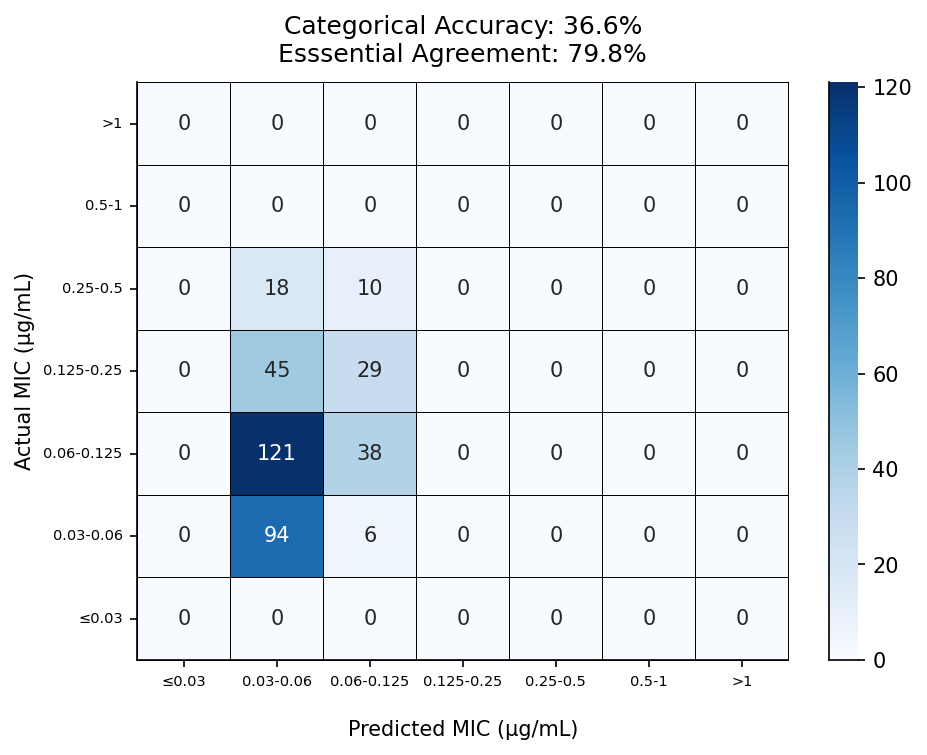

In [19]:
drug = "RIF"
model_path = "CNN_results/RIF_amino_acid"

_, _, _, _ = compare_predicted_actual_MIC(drug, model_path, palette=sns.color_palette("Blues", as_cmap=True), model="CNN")#, saveName=f"./figures/{drug}_CNN_predictions_heatmap.svg")

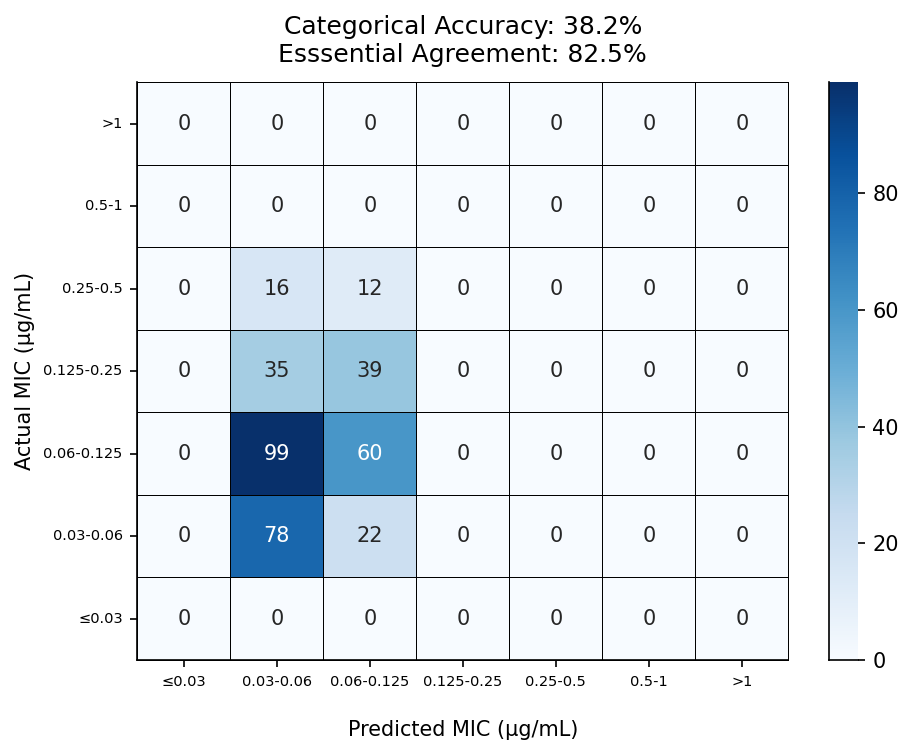

In [20]:
drug = "RIF"
model_path = "CNN_results/RIF_lineage_amino_acid"

RIF_pred, _, _, _ = compare_predicted_actual_MIC(drug, model_path, palette=sns.color_palette("Blues", as_cmap=True), model="CNN", saveName=f"./figures/{drug}_CNN_predictions_heatmap.svg")

In [29]:
isolate_variants.query("SampleID in @RIF_pred.ROLLINGDB_ID & confidence in ['1) Assoc w R', '2) Assoc w R - Interim'] & drug=='Rifampicin'")

,SampleID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence


In [23]:
def fishers_exact_test_single_variant(variant):

    # variant and high MIC
    x_11 = rpoBC_variants.query("variant==@variant & high_MIC==1").pid.nunique()
    
    # no variant and high MIC
    x_21 = len(list(set(rpoBC_variants.query("high_MIC==1").pid) - set(rpoBC_variants.query("variant==@variant & high_MIC==1").pid)))
    
    # variant and low MIC
    x_12 = rpoBC_variants.query("variant==@variant & high_MIC==0").pid.nunique()
    
    # no variant and low MIC
    x_22 = len(list(set(rpoBC_variants.query("high_MIC==0").pid) - set(rpoBC_variants.query("variant==@variant & high_MIC==0").pid)))
    
    assert x_11 + x_21 + x_12 + x_22 == rpoBC_variants.pid.nunique()

    # Create a 2x2 contingency table
    contingency_table = [[x_11, x_21], [x_12, x_22]]
    
    # Perform Fisher's exact test
    odds_ratio, p_value = st.fisher_exact(contingency_table)
    
    return odds_ratio, p_value

In [25]:
# df_fishers = pd.DataFrame(columns = ['variant', 'OR', 'pval'])
# i = 0

# for variant in rpoBC_variants.variant.unique():

#     odds_ratio, pval = fishers_exact_test_single_variant(variant)

#     df_fishers.loc[i, :] = [variant, odds_ratio, pval]
#     i += 1

# _, bh_pvals, _, _ = sm.multipletests(df_fishers['pval'], method='fdr_bh', is_sorted=False, returnsorted=False)
# df_fishers['BH_pval'] = bh_pvals

# Isoniazid

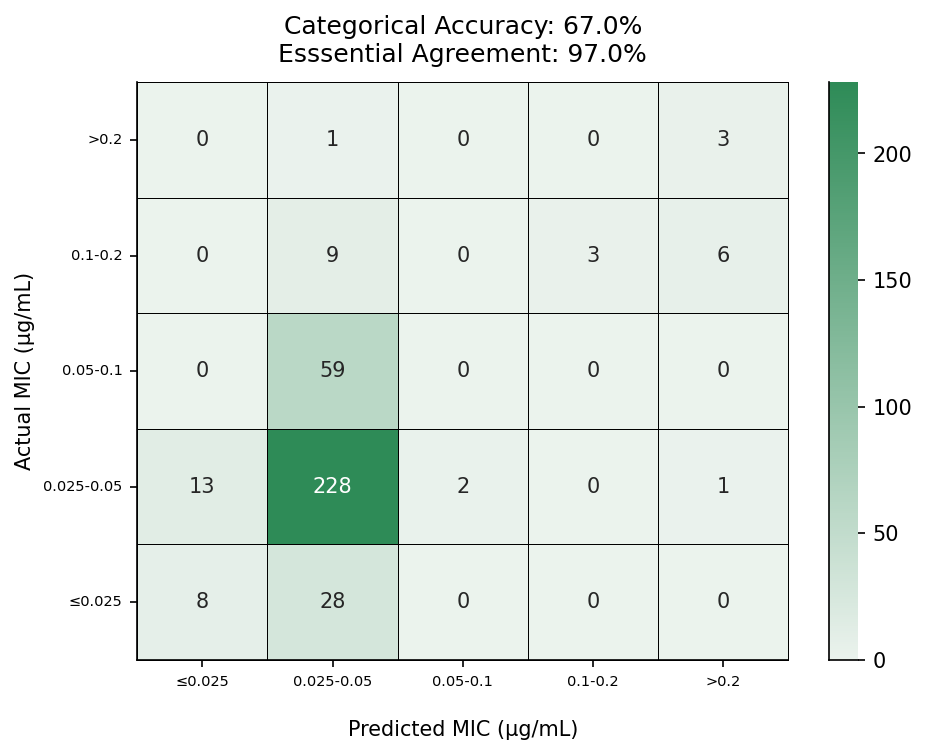

In [21]:
drug = "INH"
model_path = "CNN_results/INH_amino_acid"

_, _, _, _ = compare_predicted_actual_MIC(drug, model_path, palette=sns.light_palette("seagreen", as_cmap=True), model="CNN")#, saveName=f"./figures/{drug}_CNN_predictions_heatmap.svg")

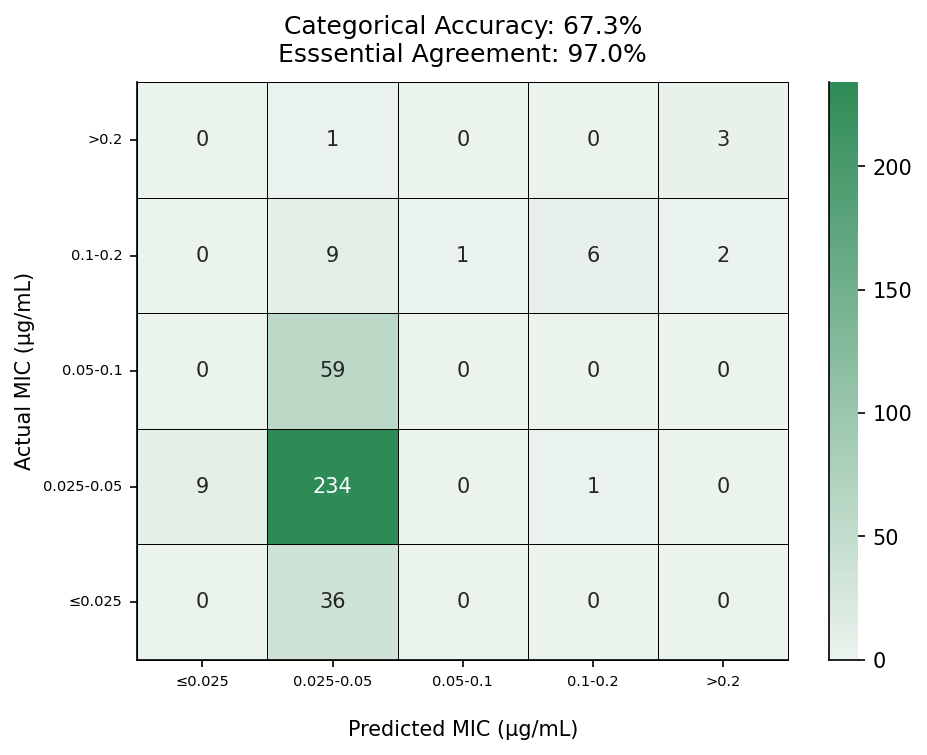

In [22]:
drug = "INH"
model_path = "CNN_results/INH_lineage_amino_acid"

INH_pred, _, _, _ = compare_predicted_actual_MIC(drug, model_path, palette=sns.light_palette("seagreen", as_cmap=True), model="CNN", saveName=f"./figures/{drug}_CNN_predictions_heatmap.svg")

In [258]:
INH_pred.query("INH_lower_bound >= 0.1").shape

(22, 14)

In [259]:
len(INH_pred.query("INH_lower_bound >= 0.1"))

22

In [260]:
INH_pred.query("INH < 4 & INH_lower_bound >= 0.1")

,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,SampleID,Original_ID,pid,INH_lower_bound,INH_upper_bound,INH_midpoint,INH,INH_method,within_doubling,compute_error,pred_MIC_group


In [262]:
22/362

0.06077348066298342

In [261]:
INH_pred.query("INH >= 4 & INH_lower_bound < 0.1")

,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,SampleID,Original_ID,pid,INH_lower_bound,INH_upper_bound,INH_midpoint,INH,INH_method,within_doubling,compute_error,pred_MIC_group


In [263]:
len(INH_pred.query("INH >= 4")), INH_pred.query("INH >= 4").within_doubling.mean()

(22, 0.8636363636363636)

In [265]:
INH_correct_prediction = INH_pred.query("pred_MIC >= 0.1 & INH >= 4").SampleID.values
len(INH_correct_prediction)

11

In [266]:
# isolates with INH R variants
isolates_with_INH_R_variants = isolate_variants.query("drug=='Isoniazid' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").SampleID.unique()

# isolates also measured to be INH-R
isolates_with_INH_R_variants = INH_pred.query("SampleID in @isolates_with_INH_R_variants & INH >= 4").ROLLINGDB_ID.unique()

len(isolates_with_INH_R_variants)

11

In [202]:
cc_df.query("Drug=='Isoniazid'")

,Medium,Value,Drug
0,UKMYC5,0.10,Isoniazid
1,UKMYC6,0.10,Isoniazid
35,7H11,0.20,Isoniazid
47,MGIT,0.10,Isoniazid
48,7H10,0.20,Isoniazid
58,LJ,0.20,Isoniazid
84,MYCOTB,0.12,Isoniazid


In [269]:
set(INH_correct_prediction) - set(isolates_with_INH_R_variants)

{'MFS-150'}

In [270]:
set(isolates_with_INH_R_variants) - set(INH_correct_prediction)

{'MFS-313'}

In [156]:
INH_pred.query("SampleID=='MFS-313'")

,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,SampleID,Original_ID,pid,INH_lower_bound,INH_upper_bound,INH_midpoint,INH,INH_method,within_doubling,compute_error,pred_MIC_group
90,MFS-313,-2.853552,0.069178,MFS-313,S0305-01,T0305,0.1,0.2,0.15,4.0,MGIT,1,0,3.0


In [177]:
INH_pred.query("SampleID=='MFS-150'")

,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,SampleID,Original_ID,pid,INH_lower_bound,INH_upper_bound,INH_midpoint,INH,INH_method,within_doubling,compute_error,pred_MIC_group
27,MFS-150,-1.053843,0.240842,MFS-150,242-01,T0242,0.1,0.2,0.15,4.0,MGIT,0,1,5.0


In [179]:
INH_pred.query("pred_MIC_group >= 4 & INH < 4")

,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,SampleID,Original_ID,pid,INH_lower_bound,INH_upper_bound,INH_midpoint,INH,INH_method,within_doubling,compute_error,pred_MIC_group
119,MFS-360,-1.477721,0.179528,MFS-360,S0108-01,T0108,0.025,0.05,0.0375,2.0,MGIT,0,1,4.0


# Ethambutol

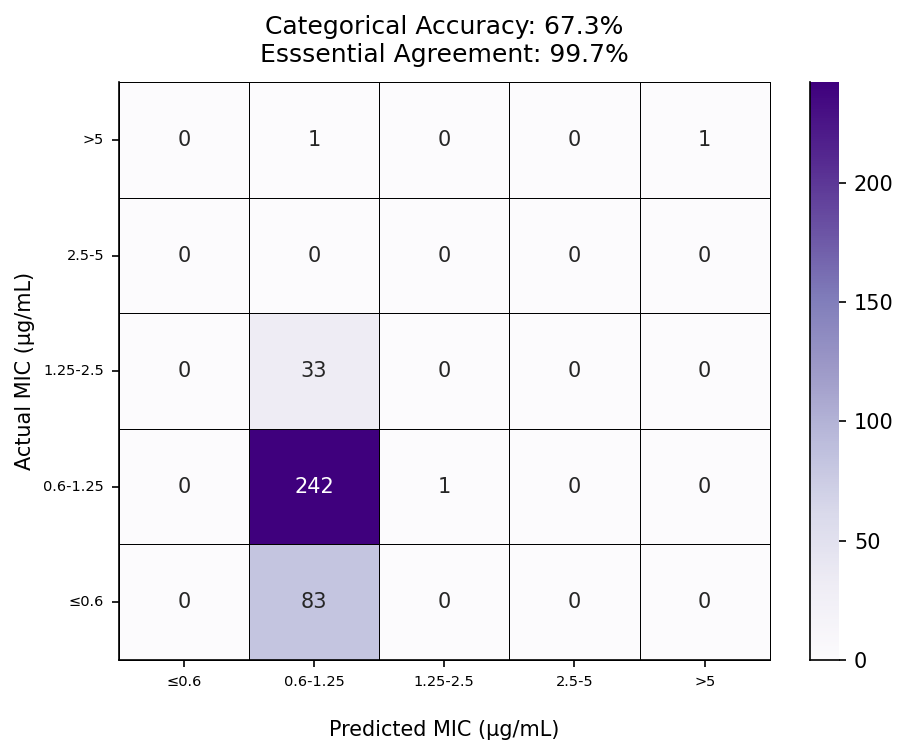

In [23]:
drug = "EMB"
model_path = "CNN_results/EMB_amino_acid"

_, _, _, _ = compare_predicted_actual_MIC(drug, model_path, palette=sns.color_palette("Purples", as_cmap=True), model="CNN")#, saveName=f"./figures/{drug}_CNN_predictions_heatmap.svg")

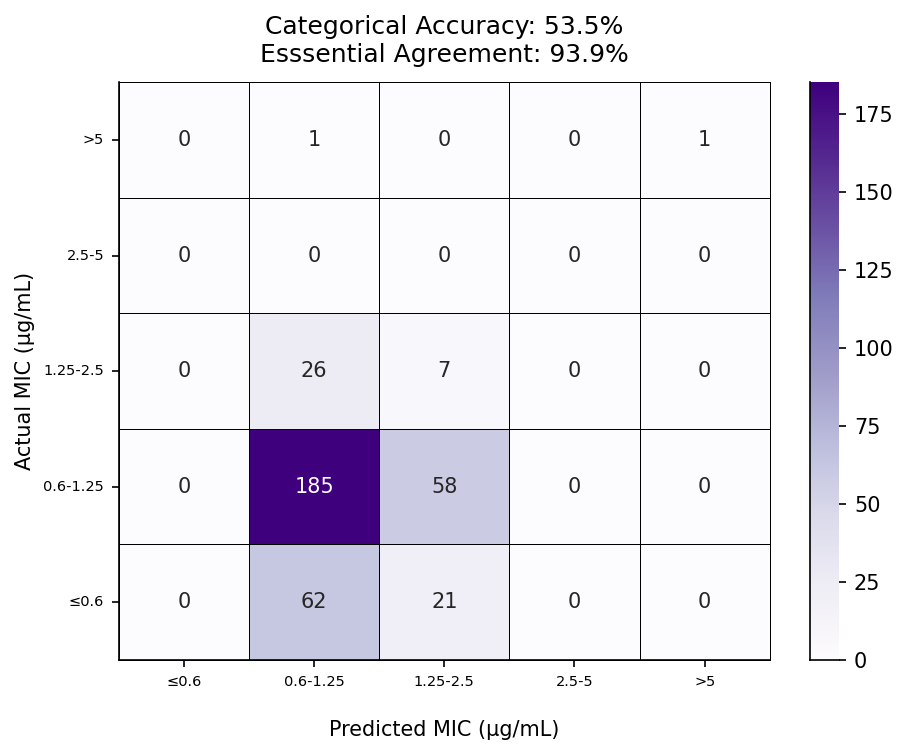

In [24]:
drug = "EMB"
model_path = "CNN_results/EMB_lineage_amino_acid"

EMB_pred, _, _, _ = compare_predicted_actual_MIC(drug, model_path, palette=sns.color_palette("Purples", as_cmap=True), model="CNN", saveName=f"./figures/{drug}_CNN_predictions_heatmap.svg")

In [64]:
isolate_variants.query("SampleID in @EMB_pred.ROLLINGDB_ID & confidence in ['1) Assoc w R', '2) Assoc w R - Interim'] & drug=='Ethambutol'")

,SampleID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
17720,MFS-533,4247429,A,G,PASS,8303.0,False,1.0,246.0,34.0,60.0,0.0,0.0,missense_variant,embB,c.916A>G,p.Met306Val,embB_p.Met306Val,Ethambutol,1) Assoc w R


# Pyrazinamide

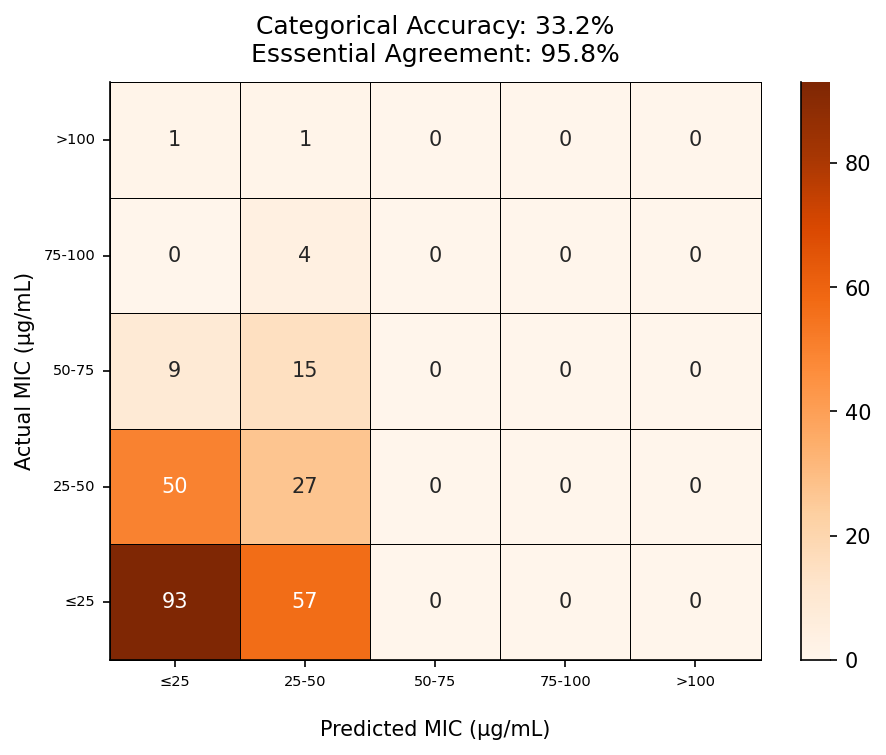

In [25]:
drug = "PZA"
model_path = "CNN_results/PZA_amino_acid"

PZA_pred, _, _, _ = compare_predicted_actual_MIC(drug, model_path, palette=sns.color_palette("Oranges", as_cmap=True), model="CNN", saveName=f"./figures/{drug}_CNN_predictions_heatmap.svg")

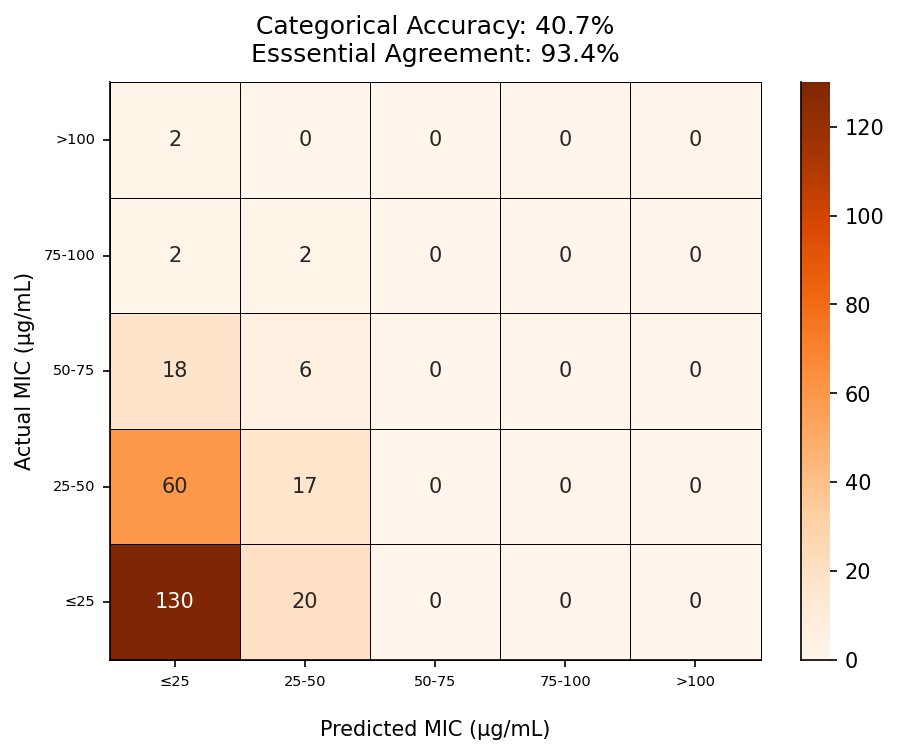

In [26]:
drug = "PZA"
model_path = "CNN_results/PZA_lineage_amino_acid"

PZA_lineage_pred, _, _, _ = compare_predicted_actual_MIC(drug, model_path, palette=sns.color_palette("Oranges", as_cmap=True), model="CNN")#, saveName=f"./figures/{drug}_CNN_predictions_heatmap.svg")

In [43]:
false_positive_samples = PZA_lineage_pred.query("pred_MIC > 100 & PZA_lower_bound == 0").ROLLINGDB_ID.values

In [44]:
isolate_variants.query("SampleID in @false_positive_samples & drug=='Pyrazinamide'")

,SampleID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
530,MFS-111,4038287,G,A,PASS,9539.0,False,1.0,294.0,33.0,60.0,0.0,0.0,synonymous_variant,clpC1,c.2418C>T,p.Asn806Asn,clpC1_c.2418C>T,Pyrazinamide,5) Not assoc w R
1566,MFS-131,4038287,G,A,PASS,14651.0,False,1.0,451.0,33.0,60.0,0.0,0.0,synonymous_variant,clpC1,c.2418C>T,p.Asn806Asn,clpC1_c.2418C>T,Pyrazinamide,5) Not assoc w R
3163,MFS-160,4038287,G,A,PASS,8968.0,False,1.0,274.0,33.0,60.0,0.0,0.0,synonymous_variant,clpC1,c.2418C>T,p.Asn806Asn,clpC1_c.2418C>T,Pyrazinamide,5) Not assoc w R
4009,MFS-176,4038287,G,A,PASS,10700.0,False,1.0,329.0,33.0,60.0,0.0,0.0,synonymous_variant,clpC1,c.2418C>T,p.Asn806Asn,clpC1_c.2418C>T,Pyrazinamide,5) Not assoc w R
4640,MFS-190,4038287,G,A,PASS,8700.0,False,1.0,270.0,32.0,60.0,0.0,0.0,synonymous_variant,clpC1,c.2418C>T,p.Asn806Asn,clpC1_c.2418C>T,Pyrazinamide,5) Not assoc w R
5108,MFS-25,4038287,G,A,PASS,7711.0,False,1.0,232.0,33.0,60.0,0.0,0.0,synonymous_variant,clpC1,c.2418C>T,p.Asn806Asn,clpC1_c.2418C>T,Pyrazinamide,5) Not assoc w R
6895,MFS-293,4038287,G,A,PASS,10358.0,False,1.0,329.0,32.0,60.0,0.0,0.0,synonymous_variant,clpC1,c.2418C>T,p.Asn806Asn,clpC1_c.2418C>T,Pyrazinamide,5) Not assoc w R
12165,MFS-401,4038287,G,A,PASS,9053.0,False,1.0,276.0,33.0,60.0,0.0,0.0,synonymous_variant,clpC1,c.2418C>T,p.Asn806Asn,clpC1_c.2418C>T,Pyrazinamide,5) Not assoc w R
13787,MFS-439,4038287,G,A,PASS,7292.0,False,1.0,227.0,33.0,60.0,0.0,0.0,synonymous_variant,clpC1,c.2418C>T,p.Asn806Asn,clpC1_c.2418C>T,Pyrazinamide,5) Not assoc w R
18126,MFS-542,4038287,G,A,PASS,8584.0,False,1.0,262.0,33.0,60.0,0.0,0.0,synonymous_variant,clpC1,c.2418C>T,p.Asn806Asn,clpC1_c.2418C>T,Pyrazinamide,5) Not assoc w R


In [63]:
isolate_variants_full.query("variant=='clpC1_c.2418C>T'").merge(df_PZA_augment, on='ROLLINGDB_ID').query("category=='train_set'")[['ROLLINGDB_ID', 'PZA_lower_bound', 'PZA_upper_bound', 'DB_OF_ORIGIN']].DB_OF_ORIGIN.value_counts()

DB_OF_ORIGIN
farhat_internal           288
WHO_catalog                39
WHO_catalog_binary         25
farhat_internal_binary      2
Name: count, dtype: int64

In [66]:
isolate_variants_full.query("variant=='clpC1_c.2418C>T'").merge(df_PZA_augment, on='ROLLINGDB_ID').query("category=='train_set' & PZA_lower_bound >= 100")[['ROLLINGDB_ID', 'PZA_lower_bound', 'PZA_upper_bound', 'DB_OF_ORIGIN']]

,ROLLINGDB_ID,PZA_lower_bound,PZA_upper_bound,DB_OF_ORIGIN
1,SAMEA3401012,100.0,inf,WHO_catalog_binary
2,SAMEA3402908,100.0,inf,WHO_catalog_binary
4,SAMEA3402929,100.0,inf,WHO_catalog_binary
7,SAMEA3414466,175.0,200.0,farhat_internal
9,SAMN05830709,500.0,inf,farhat_internal
...,...,...,...,...
485,SAMN08708215,100.0,inf,WHO_catalog_binary
486,SAMN08708430,100.0,inf,WHO_catalog_binary
487,SAMN08709288,100.0,inf,WHO_catalog_binary
488,SAMN08732295,100.0,inf,WHO_catalog_binary


In [74]:
isolate_variants_full.query("ROLLINGDB_ID=='SAMEA3401012' & drug=='Pyrazinamide'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
86363,SAMEA3401012,1834683,C,T,PASS,5930.0,False,0.99,183.0,34.0,60.0,0.0,0.0,missense_variant,rpsA,c.1142C>T,p.Ala381Val,rpsA_p.Ala381Val,Pyrazinamide,3) Uncertain significance
86368,SAMEA3401012,2289090,T,C,PASS,5552.0,False,1.00,155.0,36.0,60.0,0.0,0.0,missense_variant,pncA,c.152A>G,p.His51Arg,pncA_p.His51Arg,Pyrazinamide,1) Assoc w R
86371,SAMEA3401012,4038287,G,A,PASS,4797.0,False,1.00,133.0,36.0,60.0,0.0,0.0,synonymous_variant,clpC1,c.2418C>T,p.Asn806Asn,clpC1_c.2418C>T,Pyrazinamide,5) Not assoc w R


In [61]:
df_PZA_augment.columns

Index(['ROLLINGDB_ID', 'DB_OF_ORIGIN', 'MEDIA', 'PZA_MEDIA', 'PZA_lower_bound',
       'PZA_midpoint', 'PZA_upper_bound', 'Coll2014', 'Freschi2020',
       'Lipworth2019', 'Shitikov2017', 'Stucki2016', 'F2', 'Lineage',
       'log2_F2', 'Span_CC', 'Binary', 'Stratify', 'category'],
      dtype='object')

In [45]:
df_PZA_augment = pd.read_csv(f"{data_dir}/PZA_augment/data_for_model.csv")

In [29]:
isolate_variants.query("SampleID in @PZA_pred.ROLLINGDB_ID & confidence in ['1) Assoc w R', '2) Assoc w R - Interim'] & drug=='Pyrazinamide'")

,SampleID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
22410,MFS-637,2289202,A,G,PASS,8287.0,False,1.0,246.0,34.0,60.0,0.0,0.0,missense_variant,pncA,c.40T>C,p.Cys14Arg,pncA_p.Cys14Arg,Pyrazinamide,1) Assoc w R


In [30]:
PZA_pred.dropna(subset='PZA').ROLLINGDB_ID.nunique()

257

In [31]:
PZA_pred.query("ROLLINGDB_ID=='MFS-637'")

,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,SampleID,Original_ID,pid,PZA_lower_bound,PZA_upper_bound,PZA_midpoint,PZA,PZA_method,within_doubling,compute_error,pred_MIC_group
250,MFS-637,7.671923,203.92894,MFS-637,S0208-01,T0208,NaN,NaN,NaN,NaN,NaN,0,0,5.0


In [33]:
PZA_lineage_pred.query("ROLLINGDB_ID=='MFS-637'")

,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,SampleID,Original_ID,pid,PZA_lower_bound,PZA_upper_bound,PZA_midpoint,PZA,PZA_method,within_doubling,compute_error,pred_MIC_group
250,MFS-637,5.562806,47.26845,MFS-637,S0208-01,T0208,NaN,NaN,NaN,NaN,NaN,0,0,2.0


# Distribution of MICs per Unique Sequence

In [260]:
def plot_barplot_mics_per_seq(drug, drug_full_name, mic_label_encoding_dict, saveFig=False):

    drug_col = f"s_{drug.lower()}mic_sputum_specimen_1"
    fasta_files = glob.glob(os.path.join(data_dir, drug, "fastas", "TRUST", "*.fasta"))
    combined_seq_df = []
    
    for fName in fasta_files:
        fasta_seq = [(seq.id.split(".")[0], str(seq.seq)) for seq in SeqIO.parse(fName, "fasta")]
        seq_df = pd.DataFrame(fasta_seq)
        seq_df.columns = ["ROLLINGDB_ID", os.path.basename(fName).split(".")[0]]
        combined_seq_df.append(seq_df)
    
    combined_seq_df = reduce(lambda x, y: pd.merge(x, y, on = 'ROLLINGDB_ID'), combined_seq_df).set_index('ROLLINGDB_ID')
    
    # string concatenate (join) all loci
    combined_seq_df = pd.DataFrame(combined_seq_df.apply(''.join, axis=1))
    combined_seq_df.columns = ['Seq']
    combined_seq_df = combined_seq_df.reset_index()
    
    combined_seq_df = combined_seq_df.merge(df_trust[['ROLLINGDB_ID', 'pid']].merge(df_trust_patients[['pid', drug_col]].dropna(axis=0), on='pid'), left_on='ROLLINGDB_ID', right_on='SampleID')
    del combined_seq_df['ROLLINGDB_ID']
    
    seq_num_mapping = dict(zip(combined_seq_df.Seq.unique(), np.arange(len(combined_seq_df.Seq.unique())).astype(str)))
    combined_seq_df["Seq_Num"] = combined_seq_df["Seq"].map(seq_num_mapping)
    
    _, seq_counts = np.unique(combined_seq_df["Seq_Num"], return_counts=True)

    # minimum number of isolates with a given sequence -- should be at least 2, otherwise there is just a single isolate with an MIC. that would just be clutter
    isolate_thresh = 2
    
    # keep only unique sequences with at least 2 isolates
    # plot_df = combined_seq_df.groupby('Seq_Num').filter(lambda x: len(x) >= isolate_thresh)
    
    # keep only unique sequences with at least 2 different measured MICs
    plot_df = combined_seq_df.groupby('Seq_Num').filter(lambda x: x[drug_col].nunique() >= isolate_thresh)
    
    seq_num_order = plot_df.groupby("Seq_Num")[drug_col].mean().sort_values(ascending=True).index.values
    
    plot_df_matrix = pd.DataFrame(plot_df.groupby('Seq_Num')[drug_col].value_counts()).reset_index().pivot(index="Seq_Num", columns=drug_col, values="count").fillna(0).astype(int)
    plot_df_matrix = plot_df_matrix.loc[seq_num_order]
    
    totals_by_seq_group = plot_df_matrix.sum(axis=1).values

    if drug == 'RIF':
        colors = sns.color_palette("Blues", n_colors=len(plot_df_matrix.columns))
    elif drug == 'PZA':
        colors = sns.color_palette("Oranges", n_colors=len(plot_df_matrix.columns))
    elif drug == 'INH':
        sns.light_palette("seagreen", n_colors=len(plot_df_matrix.columns))
    elif drug == 'EMB':
        colors = sns.light_palette("Purples", n_colors=len(plot_df_matrix.columns))
    
    plot_df_matrix_percents = plot_df_matrix.copy()
    
    # convert to percentages
    for col in plot_df_matrix_percents.columns:
        plot_df_matrix_percents[col] = plot_df_matrix_percents[col] / totals_by_seq_group * 100
        
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    # keep track of all the groups to increase the start value of the next bar
    prev_vals_array = np.zeros(len(plot_df_matrix_percents))
    
    for i, mic_group in enumerate(plot_df_matrix_percents.columns):        
                                
        ax.bar(seq_num_order, 
               plot_df_matrix_percents[mic_group], 
               color=colors[i], 
               bottom = prev_vals_array, 
               edgecolor="black",
               linewidth=0.7,
               label=mic_group,
               alpha=0.75,
              )
    
    
        # plot the bar sizes (percentages) and the true counts
        for k, seq_group in enumerate(plot_df_matrix_percents.index.values):
    
            val = plot_df_matrix_percents.loc[seq_group, mic_group]
                
            # bottom of the current box    
            y_lower = plot_df_matrix_percents.loc[seq_group, plot_df_matrix_percents.columns[:i + 1]].values.sum()

            # top of the current box
            y_upper = plot_df_matrix_percents.loc[seq_group, plot_df_matrix_percents.columns[:i]].values.sum()

            y_pos = np.mean([y_lower, y_upper])
    
            if val > 0:
                combined_label = f"{int(np.round(val))}%\n(N={plot_df_matrix.loc[seq_group, mic_group]})"
                
                # small numbers for which the bars are too short to accommodate the whole number, put on top
                if val < 3:
                    ax.text(seq_group, y_pos + 1, combined_label, ha='center', va='bottom', fontsize='8')
                else:
                    ax.text(seq_group, y_pos, combined_label, ha='center', va='center', fontsize='8')
    
        # increment bottom
        prev_vals_array += plot_df_matrix_percents[mic_group]
        
        # adjust legend manually to show the exact MIC ranges with the colors, NOT the integer groups
    
    handles, labels = ax.get_legend_handles_labels()    
    
    # RIF_label_encoding_dict keys are integers, but labels are strings
    mic_labels = [mic_label_encoding_dict[int(float(val))] for val in labels]
    
    # Set the legend handles
    ax.legend(handles, mic_labels)
    plt.xticks([], [])
    ax.margins(x=0.01)
    sns.despine()
    
    sns.move_legend(ax, fontsize=10, title='MIC Range (µg/mL)', loc='upper right', #bbox_to_anchor=(1.05, 0.65),
                    ncol=len(colors),
                   bbox_to_anchor=(0.75, -0.02))
    
    plt.title(f"{drug_full_name} MICs for {len(plot_df)} Isolates across {len(seq_num_order)} Unique Concatenated {len(fasta_files)}-Loci Sequences\n")

    if saveFig:
        plt.savefig(f"TRUST/{drug}_barplot_MICS_by_seq.png", dpi=300, bbox_inches='tight')
    else:
        plt.show()

    return plot_df_matrix

In [261]:
_ = plot_barplot_mics_per_seq("RIF", "Rifampicin", RIF_label_encoding_dict, saveFig=True)

TypeError: reduce() of empty sequence with no initial value

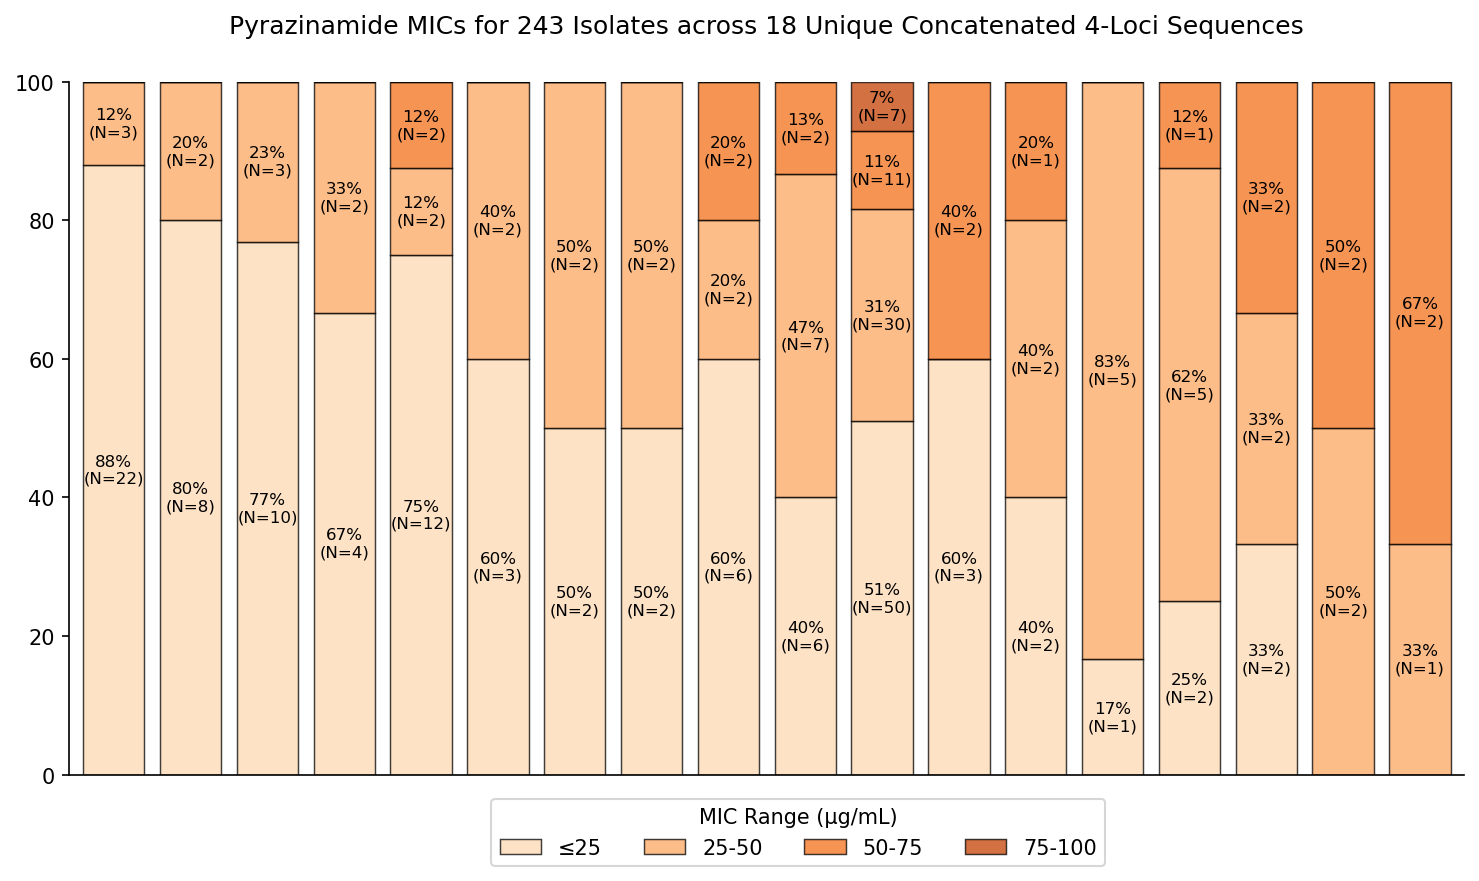

In [117]:
_ = plot_barplot_mics_per_seq("PZA", "Pyrazinamide", PZA_label_encoding_dict, saveFig=True)

# Variants in Isolates

In [126]:
isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/isolate_variants.csv.gz", compression='gzip')

In [127]:
RIF_isolate_variants = isolate_variants.query("Isolate in @RIF_patient_data.SampleID & ((POS > 759309 & POS <= 767683) | (POS > 3877432 & POS <= 3878507))").reset_index(drop=True)
PZA_isolate_variants = isolate_variants.query("Isolate in @PZA_patient_data.SampleID & ((POS > 2286526 & POS <= 2291268) | (POS > 4038050 & POS <= 4040980) | (POS > 1833379 & POS <= 1836386) | (POS > 4042940 & POS <= 4046302))").reset_index(drop=True)

len(RIF_isolate_variants), len(PZA_isolate_variants)

(477, 1124)

In [128]:
def get_syn_variant_counts_by_sample(isolate_variants_df, patient_data_df, drug):

    for i, row in isolate_variants_df.iterrows():
    
        if pd.isnull(row['PROT']):
            isolate_variants_df.loc[i, 'MUT'] = row['GENE'] + '_' + row['NUC']
        else:
            if row['PROT'].replace('p.', '')[:3] == row['PROT'][-3:]:
                isolate_variants_df.loc[i, 'MUT'] = row['GENE'] + '_' + row['NUC']
                isolate_variants_df.loc[i, 'PROT'] = np.nan
            else:
                isolate_variants_df.loc[i, 'MUT'] = row['GENE'] + '_' + row['PROT']

    syn_variants = isolate_variants_df.loc[(pd.isnull(isolate_variants_df['PROT'])) & (~isolate_variants_df['GENE'].str.contains('-'))].reset_index(drop=True)

    # merge with the full list of sample IDs so that isolates without any variants are included here and have a variant count of 0
    syn_variants = syn_variants.merge(patient_data_df[['SampleID']], left_on='Isolate', right_on='SampleID', how='right')
    
    # get the number of synonymous variants per sample. Includes all samples because we merged right above
    syn_variants_by_sample = pd.DataFrame(syn_variants.groupby('SampleID')['MUT'].count()).reset_index()
    
    # add in actual and predicted MICs
    syn_variants_by_sample = syn_variants_by_sample.merge(patient_data_df[['SampleID', f's_{drug.lower()}mic_sputum_specimen_1', 'pred_MIC_group']])

    return isolate_variants_df, syn_variants_by_sample

In [133]:
RIF_isolate_variants, RIF_syn_variants_by_sample = get_syn_variant_counts_by_sample(RIF_isolate_variants, RIF_patient_data, 'RIF')
PZA_isolate_variants, PZA_syn_variants_by_sample = get_syn_variant_counts_by_sample(PZA_isolate_variants, PZA_patient_data, 'PZA')

In [138]:
pd.DataFrame(PZA_isolate_variants.loc[(~pd.isnull(PZA_isolate_variants['PROT'])) & (PZA_isolate_variants['GENE'].isin(['pncA', 'clpC1', 'rpsA', 'panD']))].MUT.value_counts())

,count
MUT,
rpsA_p.Met432Thr,12
pncA_p.Thr114Met,11
rpsA_p.Leu53Val,4
clpC1_p.Asp326Asn,1


In [142]:
pd.DataFrame(PZA_isolate_variants.loc[(pd.isnull(PZA_isolate_variants['PROT'])) & (PZA_isolate_variants['GENE'].isin(['pncA', 'clpC1', 'rpsA', 'panD']))].MUT.value_counts())

,count
MUT,
rpsA_c.636A>C,159
clpC1_c.2418C>T,47
pncA_c.195C>T,10
clpC1_c.1737G>A,7


In [143]:
pd.DataFrame(RIF_isolate_variants.loc[(pd.isnull(RIF_isolate_variants['PROT'])) & (~RIF_isolate_variants['GENE'].str.contains('-'))].MUT.value_counts())

,count
MUT,
rpoB_c.3225T>C,139
rpoC_c.1626C>G,39
rpoC_c.2701C>T,15
rpoB_c.2628T>G,9
rpoB_c.309C>T,6
rpoB_c.390C>T,3
rpoC_c.186C>T,3
rpoA_c.1026C>T,2
rpoC_c.1929G>A,1


In [124]:
for num_syn_var in np.sort(RIF_syn_variants_by_sample.MUT.unique()):

    actual_mic_group = RIF_syn_variants_by_sample.query("MUT==@num_syn_var")['s_rifmic_sputum_specimen_1'].mean()
    #pred_mic_group = RIF_syn_variants_by_samples.query("MUT==@num_syn_var")['pred_MIC_group'].mean() # these are identical because only one group was predicted for all isolates
    print(num_syn_var, actual_mic_group)

0 3.24
1 2.9226519337016574
2 2.6842105263157894
3 2.0


<Axes: xlabel='MUT', ylabel='s_rifmic_sputum_specimen_1'>

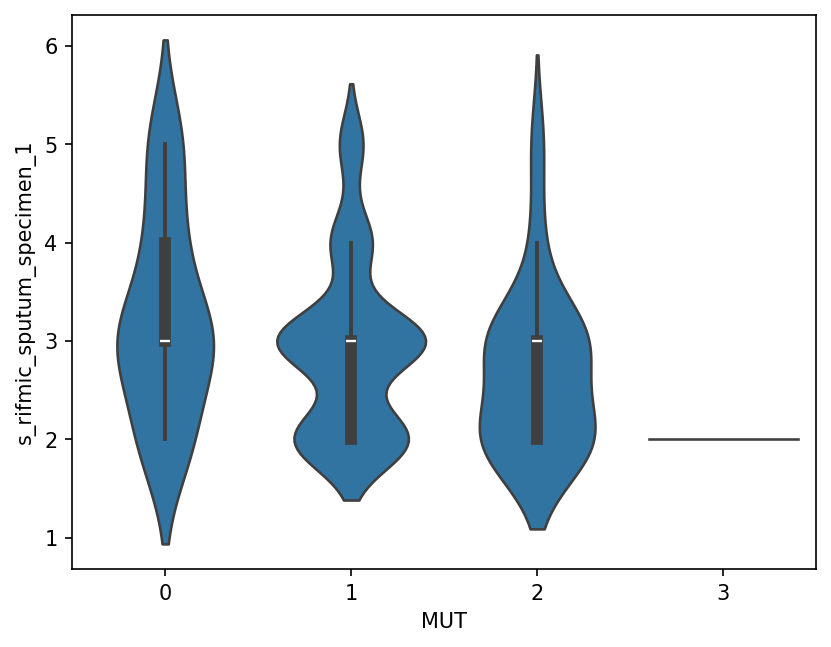

In [125]:
sns.violinplot(data=RIF_syn_variants_by_sample,
              x='MUT',
              y='s_rifmic_sputum_specimen_1'
             )